In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
import os 

In [3]:
df = pd.read_csv("../data/cleaned_ipl_tweets.csv")
df["hashtags"] = df["hashtags"].apply(eval)


df["hashtags"] = df["hashtags"].apply(
    lambda x: list(set([tag.lower() for tag in x]))
)
df = df.sample(n=10000, random_state=42)


print("Total tweets:", len(df))
print("Sample hashtags:", df["hashtags"].head(3))


Total tweets: 10000
Sample hashtags: 201569        [csk, ipl2022, pbks, cskvspbks]
536868                              [ipl2022]
469931    [vifanofthematch, lsgvcsk, ipl2022]
Name: hashtags, dtype: object


In [4]:
G = nx.Graph()

for hashtags in df["hashtags"]:
    for pair in combinations(hashtags, 2):
        if G.has_edge(pair[0], pair[1]):
            G[pair[0]][pair[1]]["weight"] += 1
        else:
            G.add_edge(pair[0], pair[1], weight=1)

edges_to_remove = [(u, v) for u, v, d in G.edges(data=True) if d["weight"] < 5]
G.remove_edges_from(edges_to_remove)

# Remove isolated nodes that have no connections after filtering
G.remove_nodes_from(list(nx.isolates(G)))

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 493
Edges: 2094


In [5]:

degree_centrality = nx.degree_centrality(G)


betweenness_centrality = nx.betweenness_centrality(G, weight="weight")


eigenvector_centrality = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)

# Top 10 each
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_between = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
top_eigen = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTOP 10 - DEGREE CENTRALITY")
for node, score in top_degree:
    print(f"{node}: {score:.4f}")

print("\nTOP 10 - BETWEENNESS CENTRALITY")
for node, score in top_between:
    print(f"{node}: {score:.4f}")

print("\nTOP 10 - EIGENVECTOR CENTRALITY")
for node, score in top_eigen:
    print(f"{node}: {score:.4f}")


TOP 10 - DEGREE CENTRALITY
ipl2022: 1.0000
ipl: 0.4573
tataipl: 0.2297
cricket: 0.1951
rcb: 0.1402
csk: 0.1362
crickettwitter: 0.1301
tataipl2022: 0.1199
mumbaiindians: 0.1199
vifanofthematch: 0.1179

TOP 10 - BETWEENNESS CENTRALITY
ipl2022: 0.6184
ipl: 0.1969
tataipl: 0.0777
ceattyres: 0.0454
rpggroup: 0.0454
cricket: 0.0429
staysafe: 0.0374
rcb: 0.0340
tataipl2022: 0.0334
cricketwinner: 0.0281

TOP 10 - EIGENVECTOR CENTRALITY
ipl2022: 0.6869
vifanofthematch: 0.6223
ipl: 0.1869
tataipl: 0.0799
cricket: 0.0706
lsgvcsk: 0.0694
rcb: 0.0691
csk: 0.0672
crickettwitter: 0.0644
cskvpbks: 0.0594


In [6]:
import community as community_louvain

# Detect communities
partition = community_louvain.best_partition(G, weight="weight")

# Add community to graph nodes
nx.set_node_attributes(G, partition, "community")

# Count communities
community_counts = Counter(partition.values())
print("Number of communities:", len(community_counts))
print("\nCommunity sizes:")
for comm, size in sorted(community_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"Community {comm}: {size} nodes")

# Top hashtags per community
print("\nTop hashtags per community:")
from collections import defaultdict
community_nodes = defaultdict(list)
for node, comm in partition.items():
    community_nodes[comm].append((node, degree_centrality[node]))

for comm, nodes in sorted(community_nodes.items()):
    top = sorted(nodes, key=lambda x: x[1], reverse=True)[:5]
    print(f"\nCommunity {comm}: {[n[0] for n in top]}")

Number of communities: 8

Community sizes:
Community 1: 238 nodes
Community 2: 118 nodes
Community 7: 50 nodes
Community 3: 37 nodes
Community 0: 30 nodes
Community 5: 14 nodes
Community 6: 3 nodes
Community 4: 3 nodes

Top hashtags per community:

Community 0: ['csk', 'chennaisuperkings', 'punjabkings', 'whistlepodu', 'msdhoni']

Community 1: ['ipl2022', 'vifanofthematch', 'mivcsk', 'cskvrcb', 'cskvpbks']

Community 2: ['ipl', 'cricket', 'rcb', 'crickettwitter', 'kkr']

Community 3: ['tataipl2022', 'gujarattitans', 'rajasthanroyals', 'contest', 'hardikpandya']

Community 4: ['savind', 'indvsa', 'indvssa']

Community 5: ['iplauction', 'iplauction2022', 'iplmegaauction', 'ipl2022megaauction', 'tataiplauction']

Community 6: ['meesho', 'meeshoapp', 'arreywaah']

Community 7: ['tataipl', 'mumbaiindians', 'mi', 'contestalert', 'delhicapitals']


C:\Users\khura\AppData\Local\Temp\ipykernel_14436\3585479412.py:19: UserWarning: Glyph 78069 (\N{EGYPTIAN HIEROGLYPH E030}) missing from font(s) DejaVu Sans.
  plt.savefig("../outputs/network_communities.png", dpi=150)
C:\Users\khura\AppData\Local\Temp\ipykernel_14436\3585479412.py:19: UserWarning: Glyph 78060 (\N{EGYPTIAN HIEROGLYPH E022}) missing from font(s) DejaVu Sans.
  plt.savefig("../outputs/network_communities.png", dpi=150)


FileNotFoundError: [Errno 2] No such file or directory: '../outputs/network_communities.png'

c:\Users\khura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 78069 (\N{EGYPTIAN HIEROGLYPH E030}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\khura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 78060 (\N{EGYPTIAN HIEROGLYPH E022}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\khura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 78069 (\N{EGYPTIAN HIEROGLYPH E030}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\khura\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 78060 (\N{EGYPTIAN HIEROGLYPH E022}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


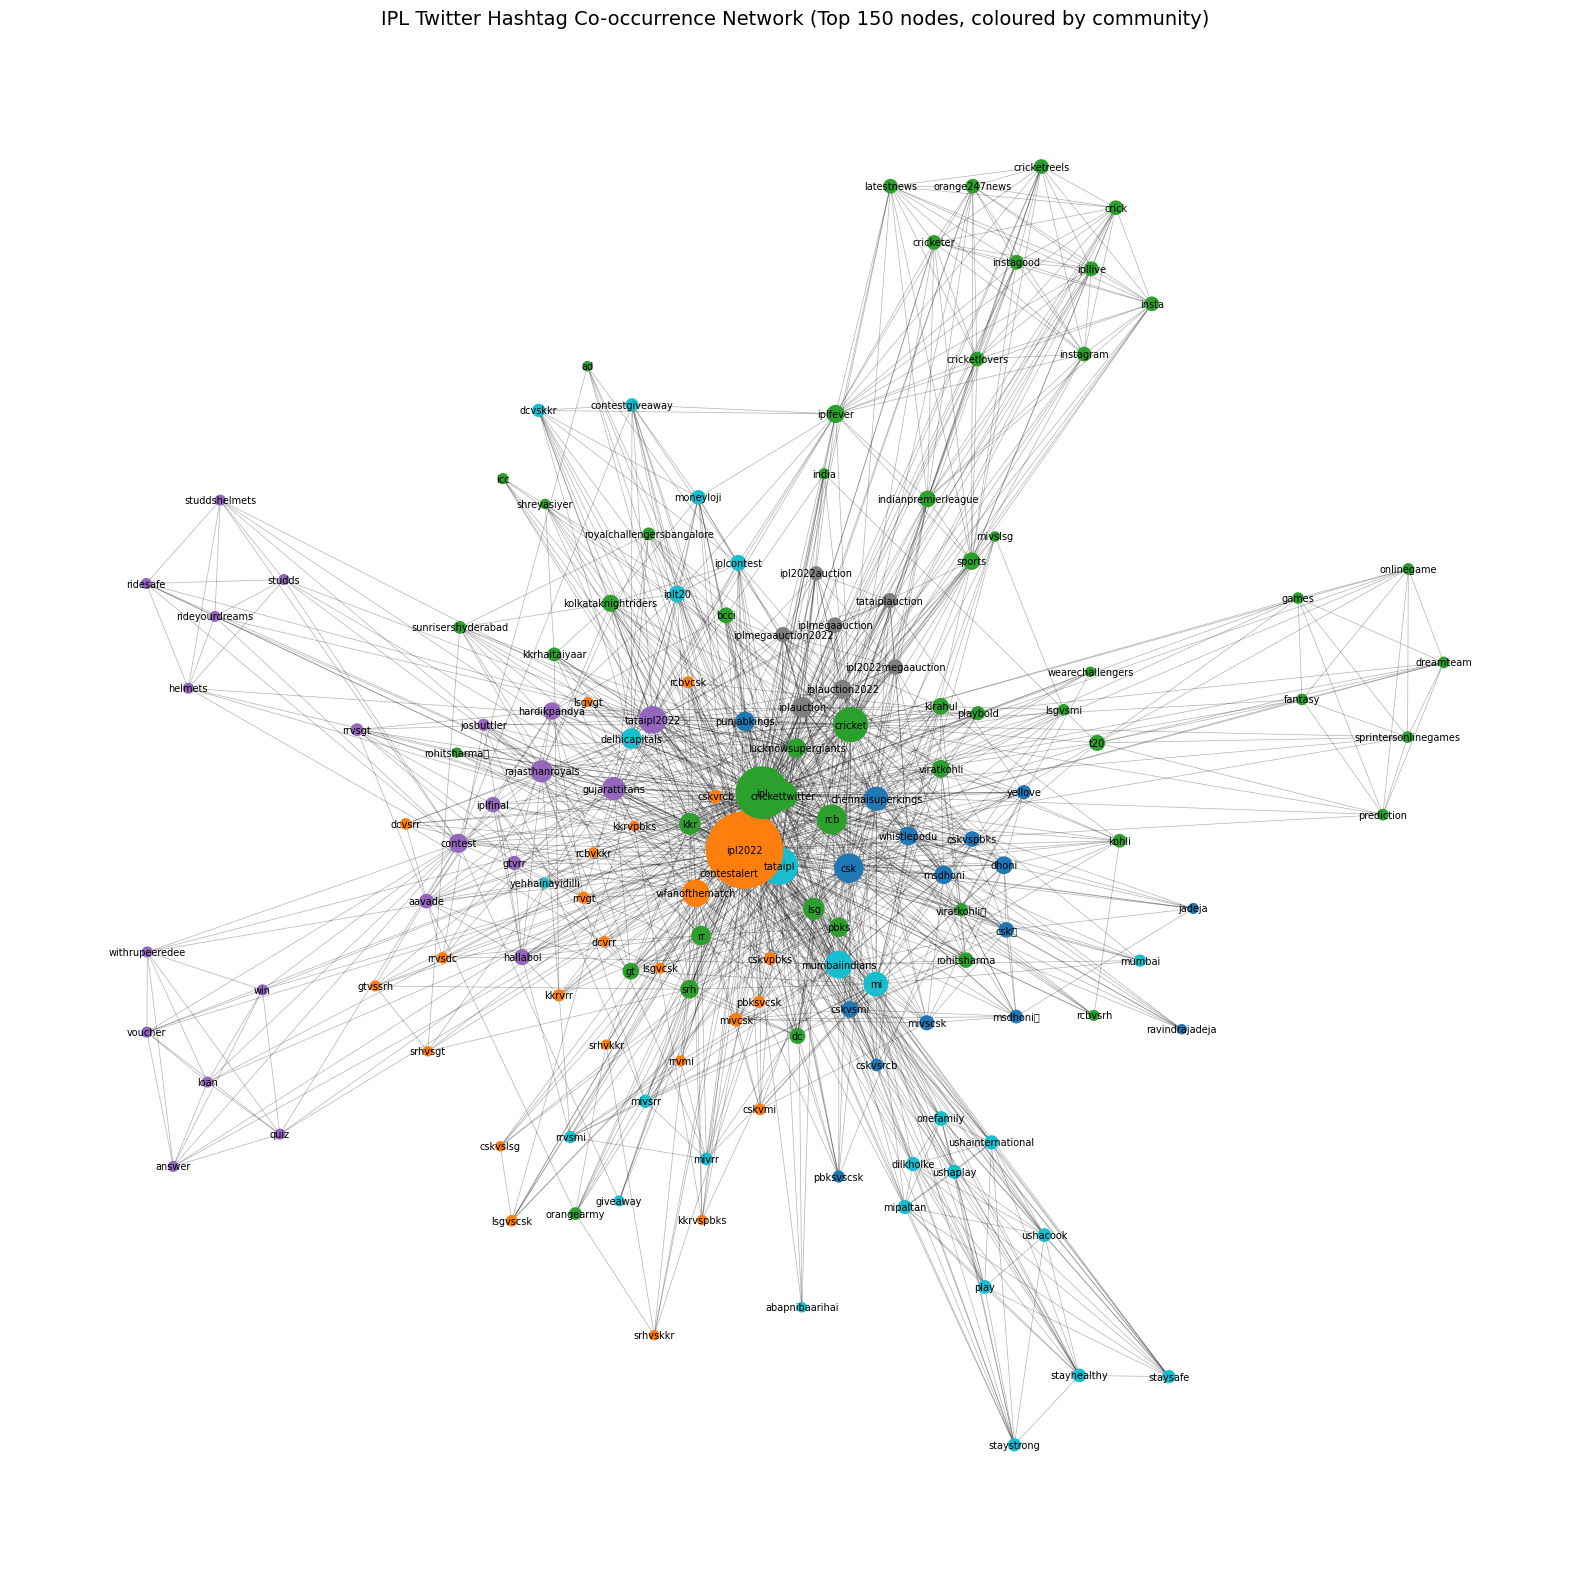

In [ ]:
plt.figure(figsize=(16, 16))

top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:150]
top_node_names = [n[0] for n in top_nodes]
subgraph = G.subgraph(top_node_names)

pos = nx.spring_layout(subgraph, k=0.5, seed=42)

colors = [partition[node] for node in subgraph.nodes()]
node_sizes = [degree_centrality[node] * 3000 for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos, node_color=colors, cmap=plt.cm.tab10, node_size=node_sizes)
nx.draw_networkx_labels(subgraph, pos, font_size=7)
nx.draw_networkx_edges(subgraph, pos, alpha=0.3, width=0.5)

plt.title("IPL Twitter Hashtag Co-occurrence Network (Top 150 nodes, coloured by community)", fontsize=14)
plt.axis("off")
plt.tight_layout()

plt.show()